In [152]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [136]:
df = pd.read_csv('snsdata.csv', delimiter=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 40 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gradyear      30000 non-null  int64  
 1   gender        27276 non-null  object 
 2   age           24914 non-null  float64
 3   friends       30000 non-null  int64  
 4   basketball    30000 non-null  int64  
 5   football      30000 non-null  int64  
 6   soccer        30000 non-null  int64  
 7   softball      30000 non-null  int64  
 8   volleyball    30000 non-null  int64  
 9   swimming      30000 non-null  int64  
 10  cheerleading  30000 non-null  int64  
 11  baseball      30000 non-null  int64  
 12  tennis        30000 non-null  int64  
 13  sports        30000 non-null  int64  
 14  cute          30000 non-null  int64  
 15  sex           30000 non-null  int64  
 16  sexy          30000 non-null  int64  
 17  hot           30000 non-null  int64  
 18  kissed        30000 non-nu

In [137]:
X = df.drop(['gradyear', 'gender', 'age', 'friends'], axis=1)
X.shape

(30000, 36)

In [138]:
scale = StandardScaler()
X_scaled = scale.fit_transform(X)
X_scaled[0][0].round(2)

np.float64(-0.33)

In [139]:
KM = KMeans(random_state=42, n_init='auto', n_clusters=9)
X_KMed = KM.fit_predict(X_scaled)
round(KM.inertia_, 2)

856276.7

In [140]:
X.loc[:, 'label'] = KM.labels_
X['label'].value_counts()

label
1    19599
2     4284
0     2201
4      941
3      902
5      851
8      754
7      467
6        1
Name: count, dtype: int64

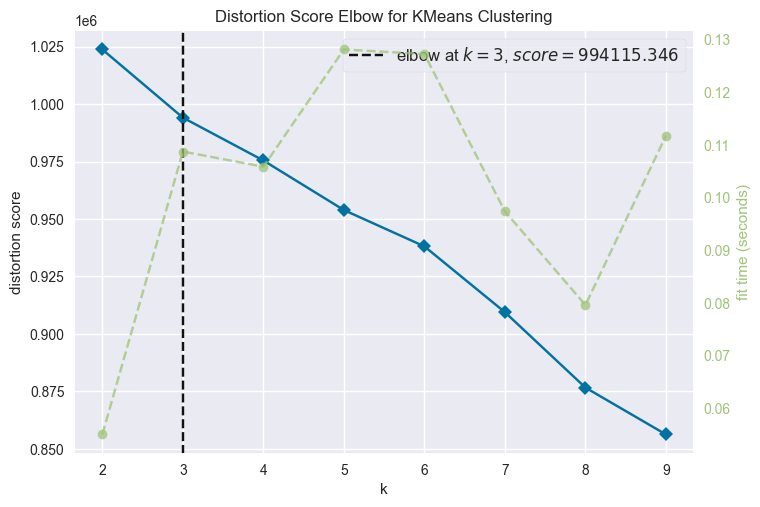

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [141]:
Elbow_M = KElbowVisualizer(KMeans(random_state=42), k=9)
Elbow_M.fit(X_scaled)
Elbow_M.show()


<Axes: xlabel='cluster', ylabel='silhouette'>

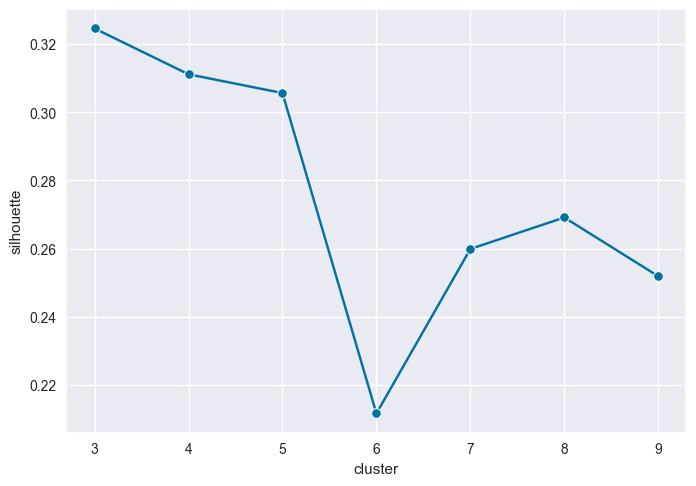

In [142]:
# напишем функцию, как и при подсчете метода локтя
def get_silhouette(cluster_num, x):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(x)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = silhouette_score(x, k_means.predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res = {"silhouette": [], "cluster": []}

for cluster_num in range(3, 10):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, X_scaled))
    silhouette_res["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df = pd.DataFrame(silhouette_res)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

In [ ]:
X_grouped = X.groupby('label').mean()#.sort_values(by=X.columns)
Features = X_grouped.apply(lambda row: list(row.sort_values(ascending=False).head(10).keys()), axis=1)


label
0    [basketball, softball, football, volleyball, b...
1    [music, god, dance, hair, shopping, band, rock...
2    [dance, music, shopping, cute, hair, mall, god...
3    [soccer, tennis, music, shopping, god, hair, d...
4    [hair, sex, music, kissed, die, rock, drugs, g...
5    [hollister, abercrombie, shopping, music, hair...
6    [blonde, sex, hair, god, death, drunk, die, fo...
7    [god, church, jesus, music, bible, hair, dance...
8    [band, marching, music, god, dance, hair, rock...
dtype: object

In [149]:
all_words = list(set(Features.sum()))
com_words = []
tbc = Features.copy()
for word in all_words:
    counter = 0
    for row in tbc:
        if word in row:
            counter=counter+1
    if counter == len(tbc.index):
        com_words.append(word)    
com_words


['god', 'hair']

In [157]:
GaussM = GaussianMixture(random_state=42, n_components=9)
GaussM_res = GaussM.fit_predict(X_scaled)
X.loc[:, 'label'] = GaussM_res
X['label'].value_counts()
#GaussM_res

label
1    17261
0     5669
8     2460
3     1658
2     1263
5      804
7      626
4      258
6        1
Name: count, dtype: int64

In [169]:
X[X['label'] == 6].mean().sort_values(ascending=False).head(3)

blonde    327.0
sex        22.0
hair       12.0
dtype: float64